In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/airline-passengers.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df["Month"] = pd.to_datetime(df.Month)

In [5]:
df.set_index(df.Month, inplace = True)

In [6]:
df.head()

,Month,Passengers
Month,,
1949-01-01,1949-01-01,112
1949-02-01,1949-02-01,118
1949-03-01,1949-03-01,132
1949-04-01,1949-04-01,129
1949-05-01,1949-05-01,121


In [7]:
df.drop(columns = ["Month"], axis = 1)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [8]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

# Convert to Time Series

In [9]:
ts = df["Passengers"]
ts.head()

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64

In [10]:
ts['1949-01-01']

np.int64(112)

In [11]:
from datetime import datetime
ts[datetime(1949,1,1)]

np.int64(112)

# Check Stationary Visually

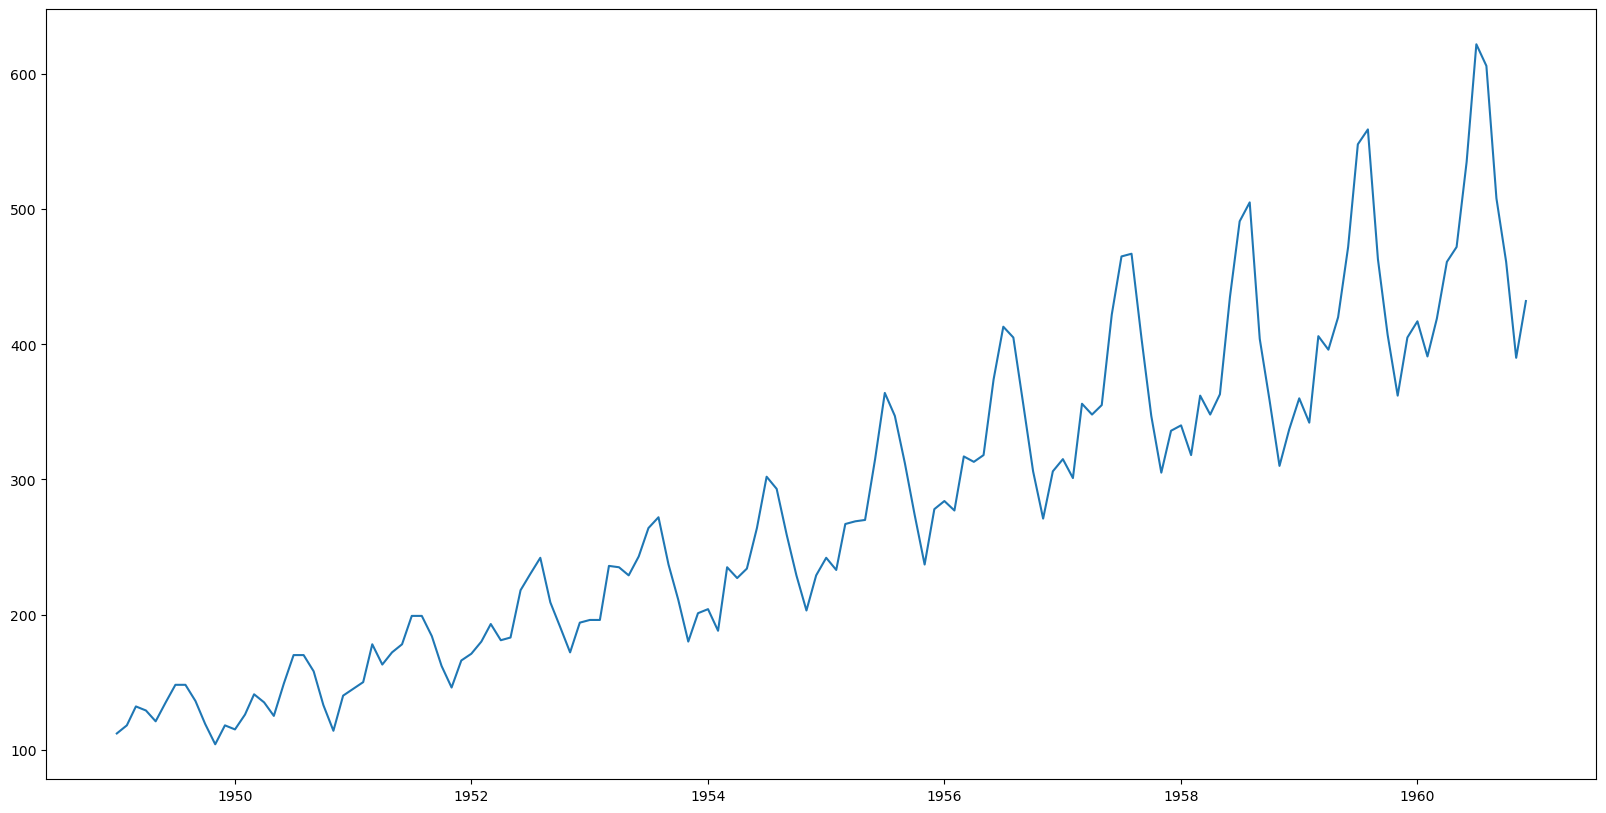

In [12]:
plt.figure(figsize=(20,10))
plt.plot(ts)
plt.show()

## Hm visually I can say there is a trend and seasonality. So data does not look Stationary. Okay lets do some test

# Stationary Test

In [13]:
def stats_test(timeData):
    #Determing rolling statistics
    rolly_mean = pd.Series(timeData).rolling(window = 12).mean()
    rolly_std = pd.Series(timeData).rolling(window = 12).std()

    #Now 3 lines to show stationary or not
    plt.figure(figsize=(20,10))
    orig = plt.plot(timeData, color='blue',label='Original')
    mean = plt.plot(rolly_mean, color='red', label='Rolling Mean')
    std = plt.plot(rolly_std, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation & Original')
    plt.show()

    #Now do ADFULLER TEST
    print("Results of ADFULLER TEST")
    adfuller_Test = adfuller(timeData, autolag = 'AIC') #AIC: Automatically best lag select karo
    adfuller_Test_Output = pd.Series(adfuller_Test[0:4], index = ['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

    #Confidentiality ka loop 
    for key, value in adfuller_Test[4].items():
        adfuller_Test_Output["Critical Value (%s)"%key] = value

    print(adfuller_Test_Output)

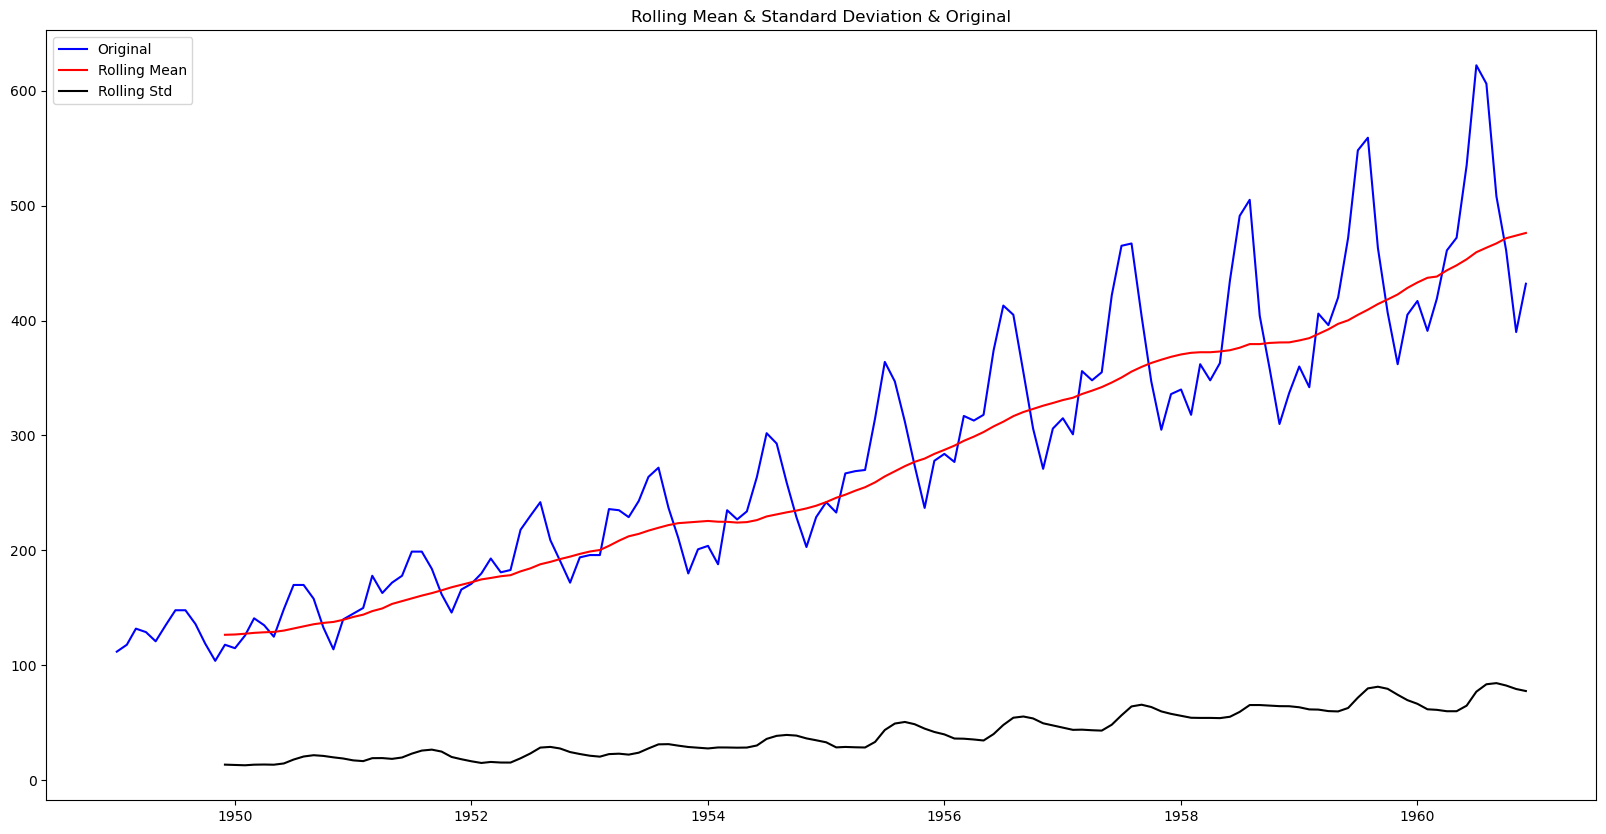

Results of ADFULLER TEST
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [14]:
stats_test(ts)

# Making It Stationary

In [15]:
ts.head()

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64

## 1. APPLYING LOG TRANSFORMATION

In [16]:
ts_log = np.log(ts)

In [17]:
ts_log.head()

Month
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Name: Passengers, dtype: float64

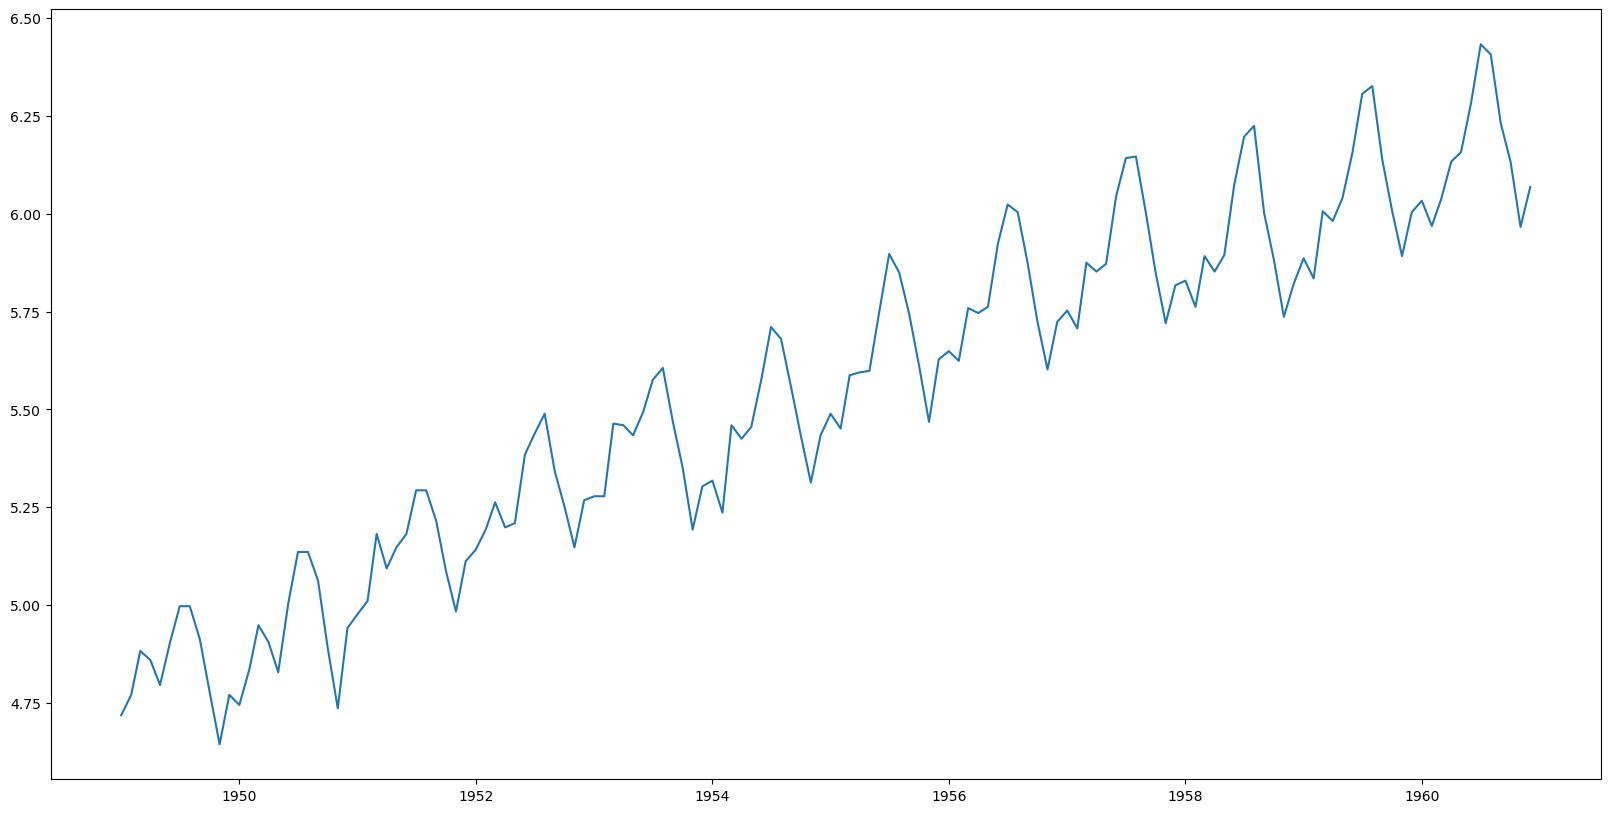

In [18]:
plt.figure(figsize=(20,10))
plt.plot(ts_log)

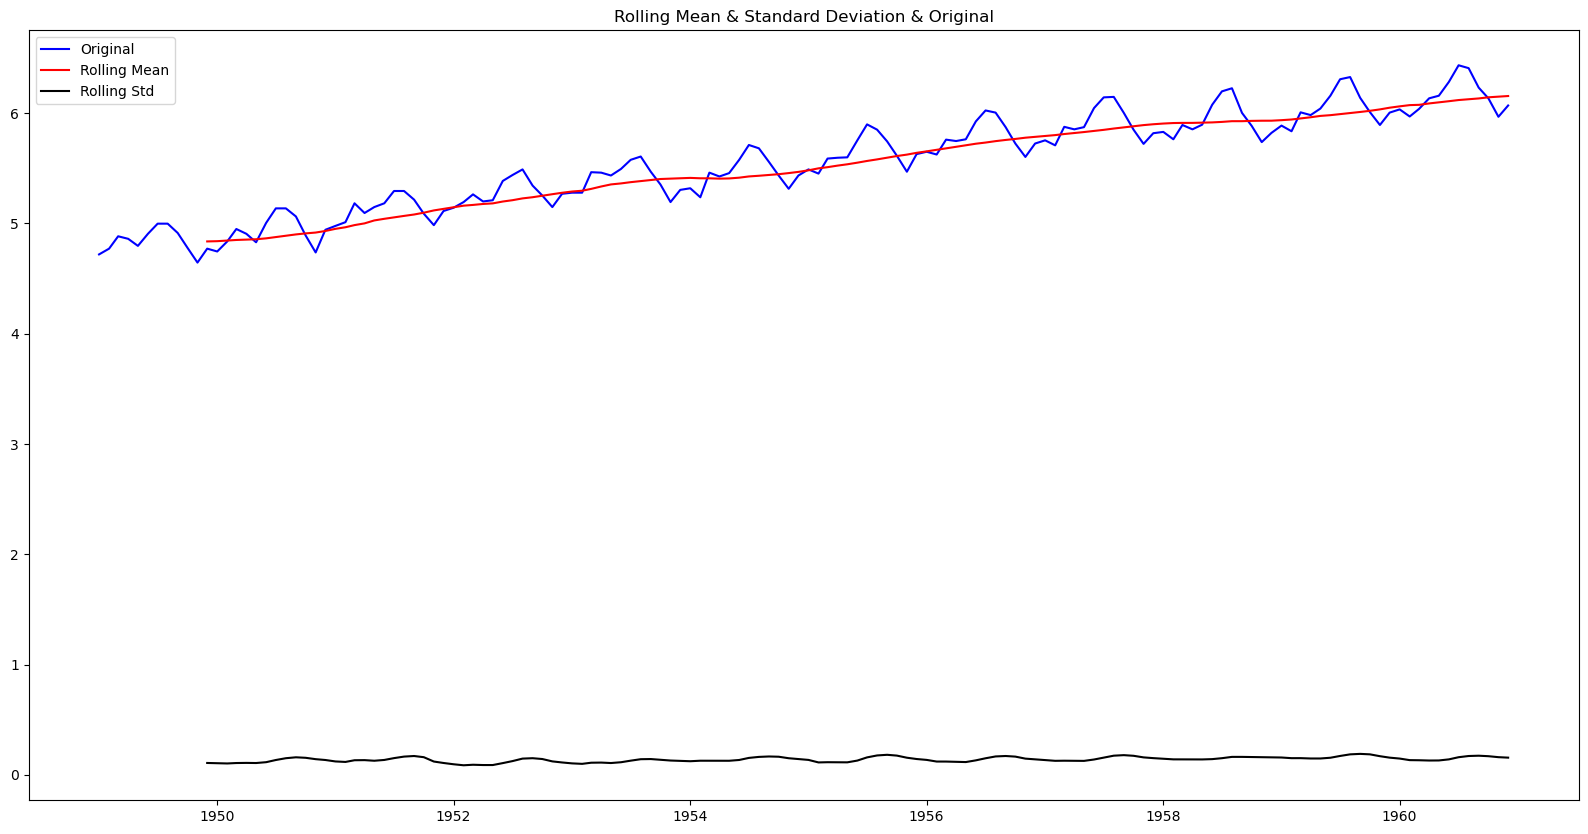

Results of ADFULLER TEST
Test Statistic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [19]:
stats_test(ts_log)

### Still not stationary, apply other methods

## 2. APPLYING DOUBLE LOG TRANSFORMATION

In [20]:
double_ts_log = np.log(ts_log)

In [21]:
double_ts_log.head()

Month
1949-01-01    1.551491
1949-02-01    1.562490
1949-03-01    1.585719
1949-04-01    1.581000
1949-05-01    1.567739
Name: Passengers, dtype: float64

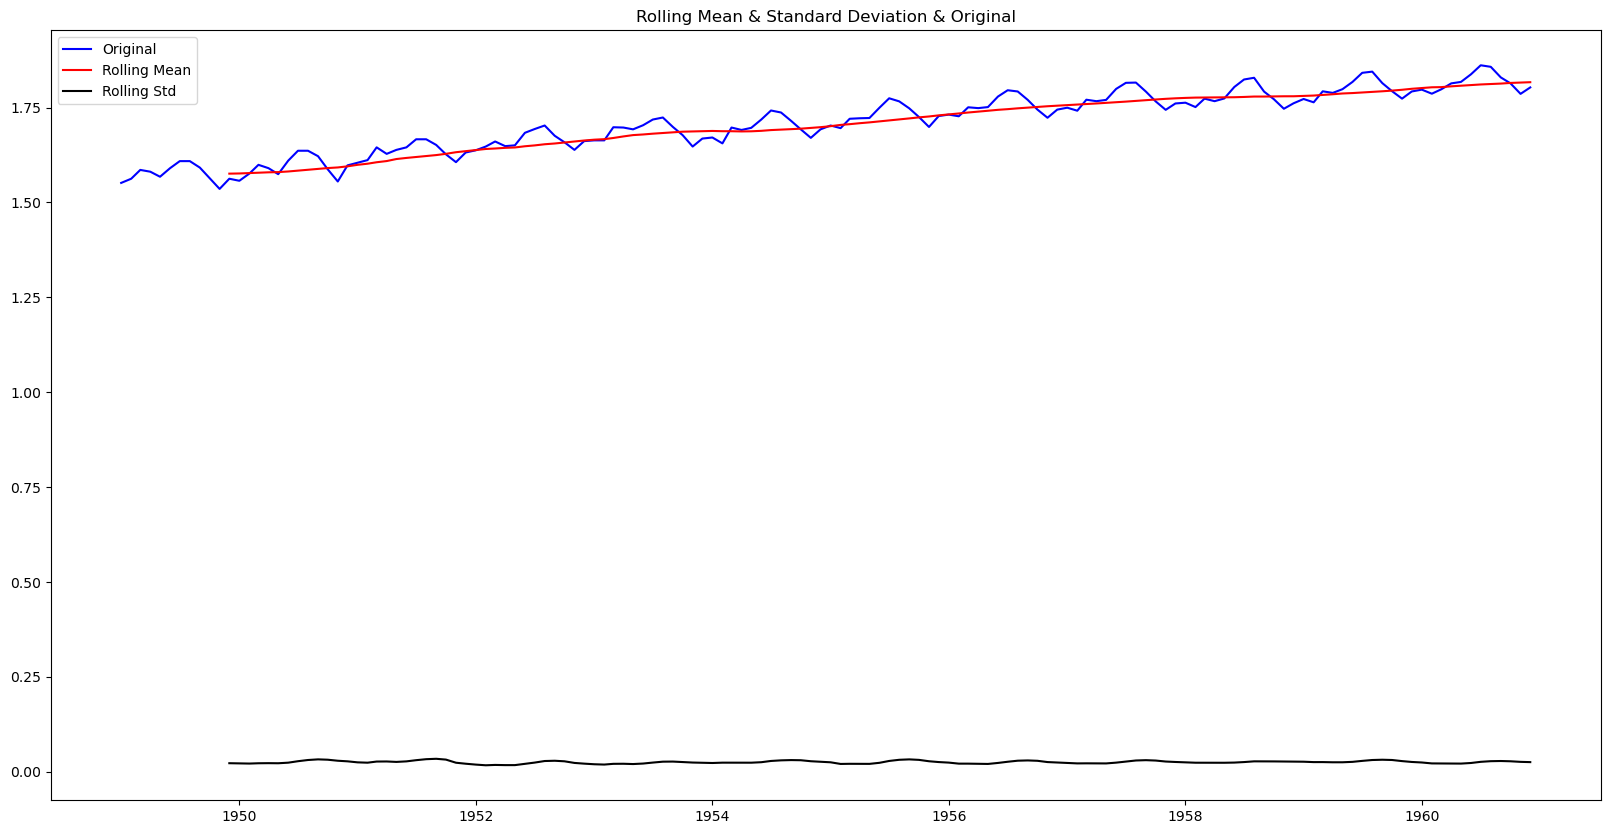

Results of ADFULLER TEST
Test Statistic                  -2.156028
p-value                          0.222590
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [22]:
stats_test(double_ts_log)

## 3. Smoothing Now

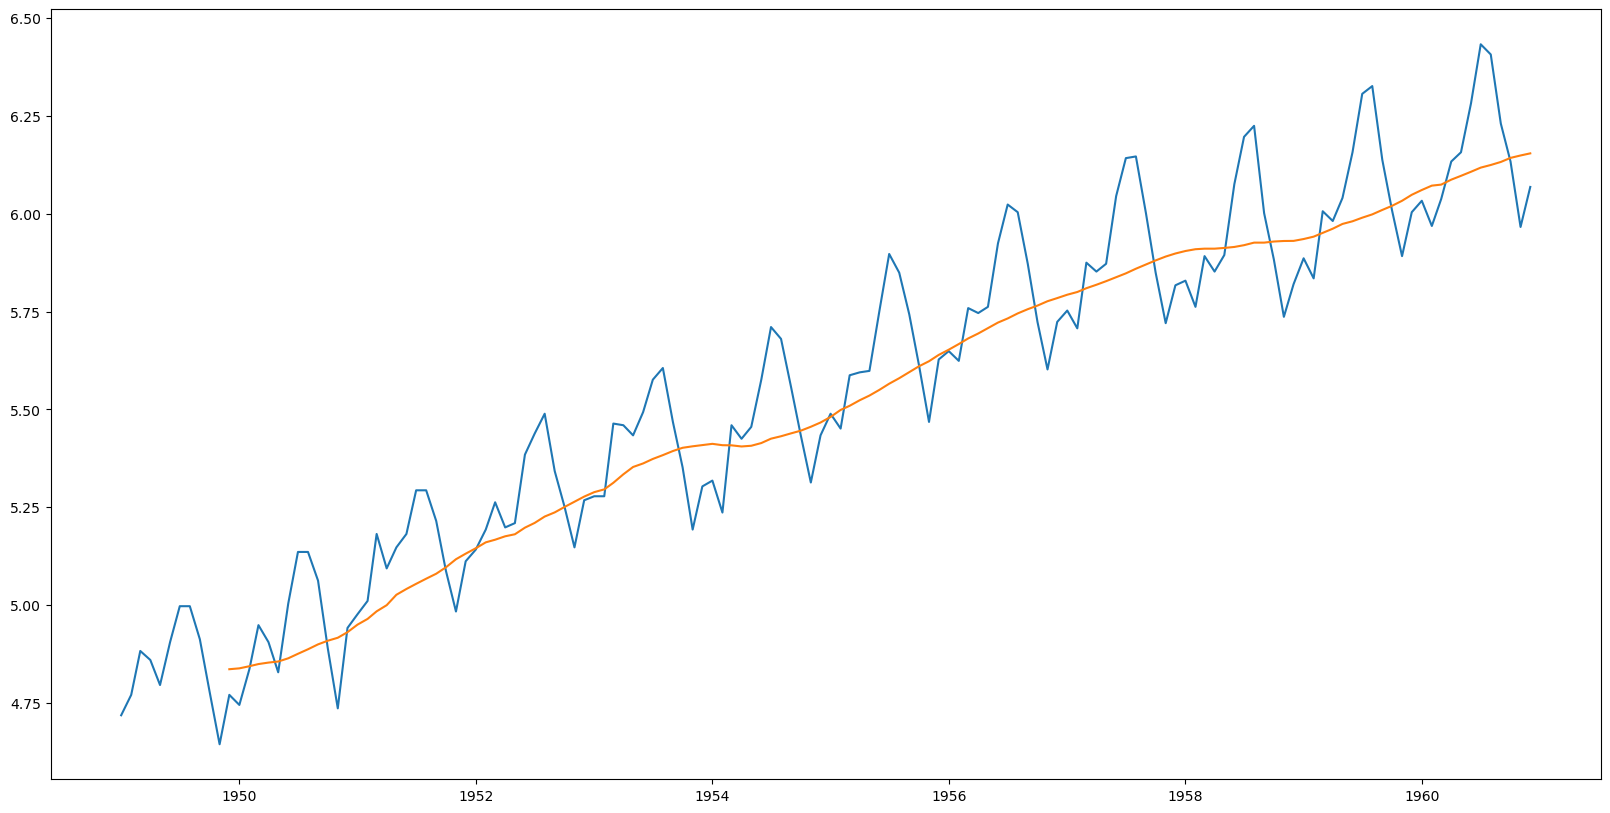

In [23]:
moving_avg = pd.Series(ts_log).rolling(window = 12).mean()
plt.figure(figsize=(20,10))
plt.plot(ts_log)
plt.plot(moving_avg)

moving_difference_remove = ts_log - moving_avg
moving_difference_remove.dropna(inplace = True)

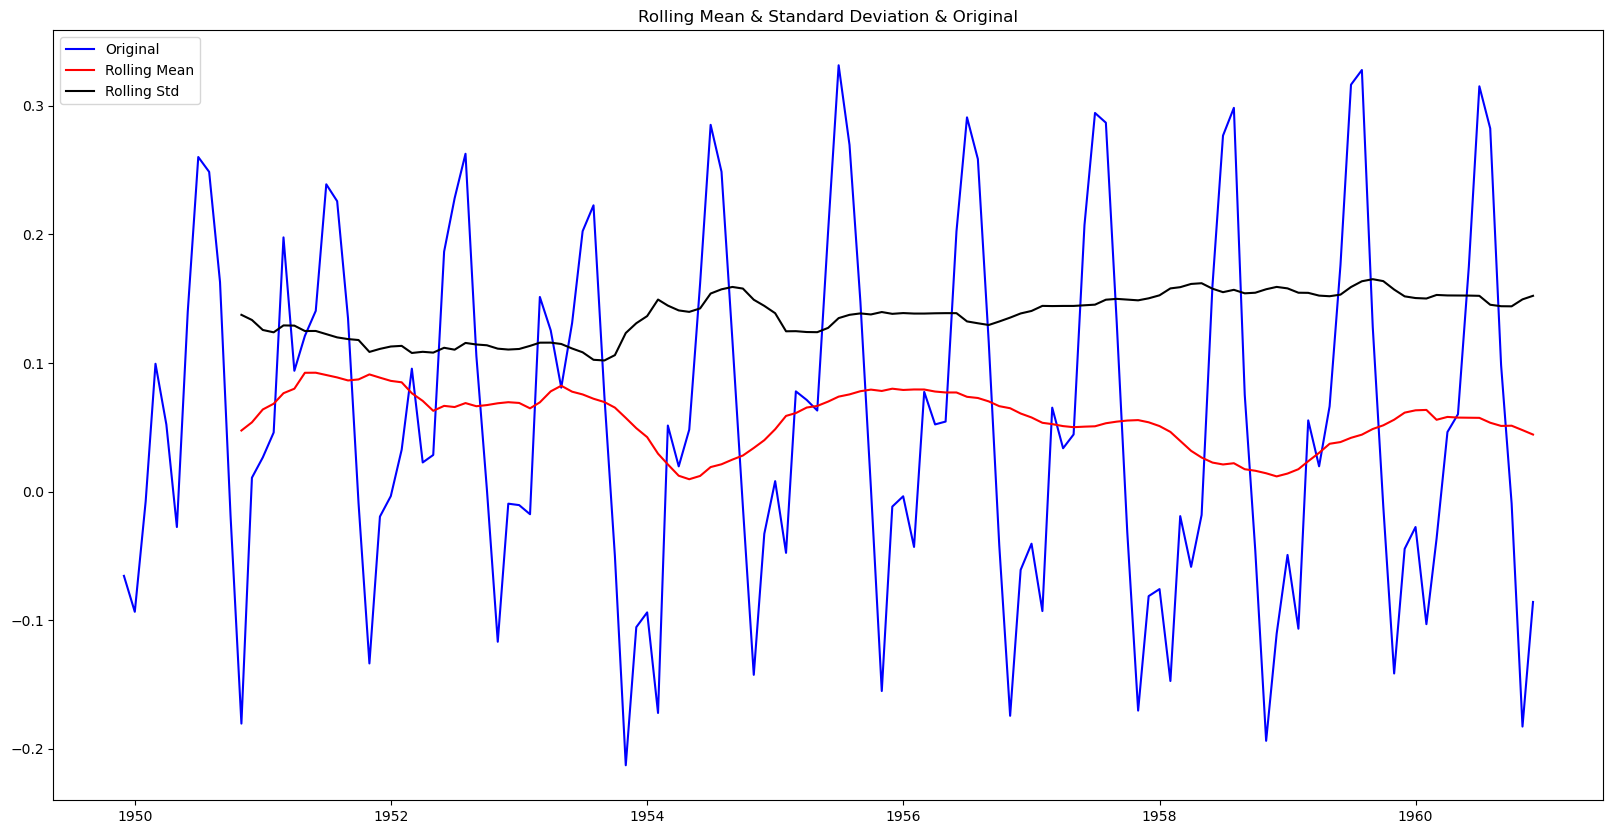

Results of ADFULLER TEST
Test Statistic                  -3.162908
p-value                          0.022235
#Lags Used                      13.000000
Number of Observations Used    119.000000
Critical Value (1%)             -3.486535
Critical Value (5%)             -2.886151
Critical Value (10%)            -2.579896
dtype: float64


In [24]:
stats_test(moving_difference_remove)

## 4. Exponential Weighted Mean Smoothing Now

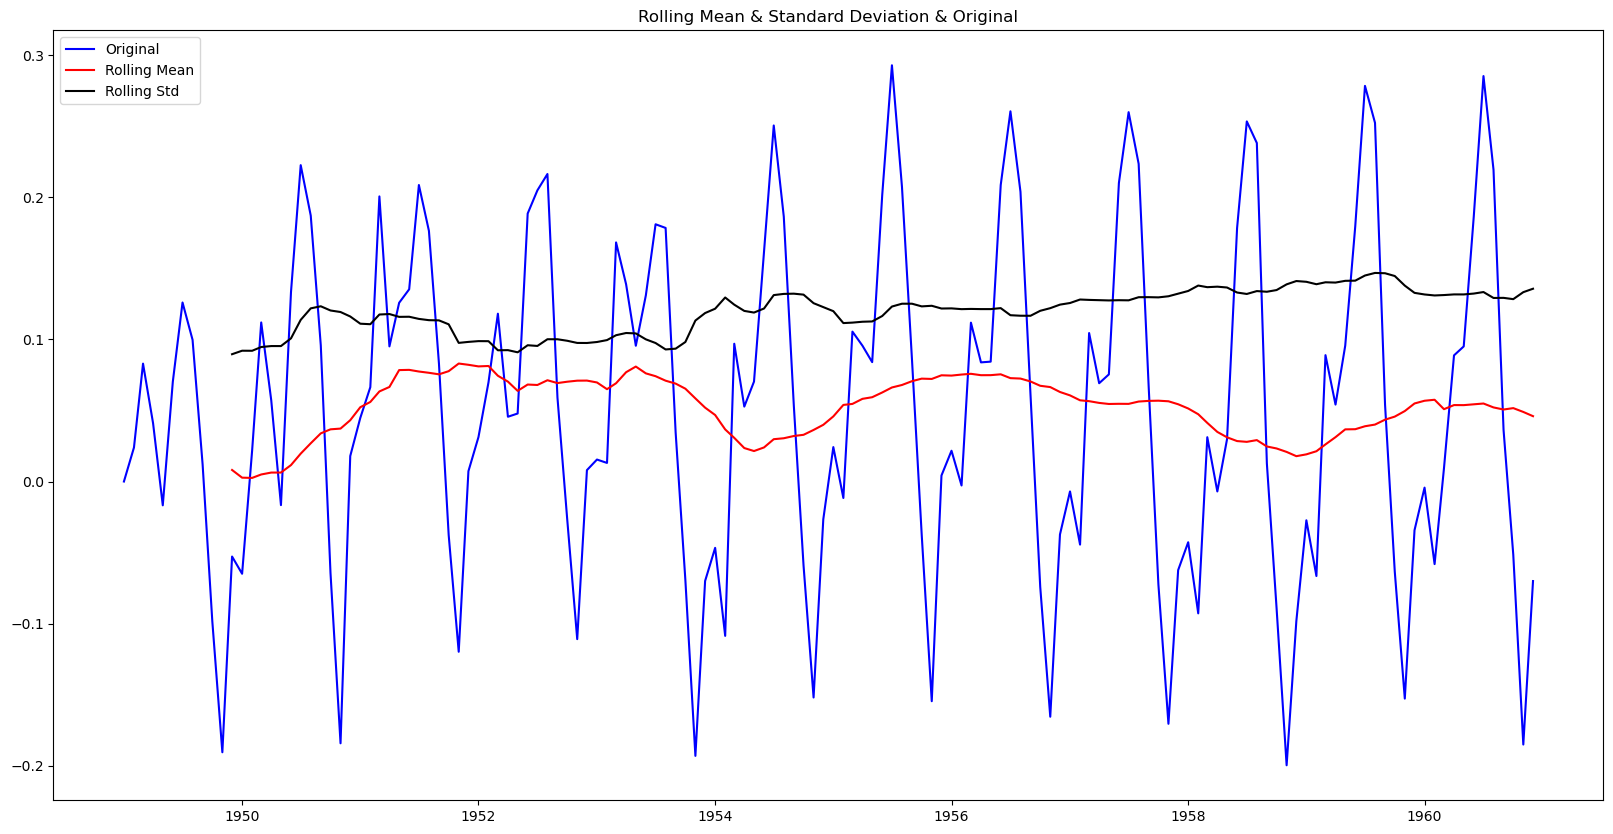

Results of ADFULLER TEST
Test Statistic                  -3.310542
p-value                          0.014414
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [25]:
exp_smoothing = ts_log.ewm(span = 12).mean()
exp_smoothing_remove_ts_log = ts_log - exp_smoothing
stats_test(exp_smoothing_remove_ts_log)

## 5. Decomposition - Remove Time Series Components (Best)

In [26]:
decomposition = seasonal_decompose(ts_log)

In [27]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

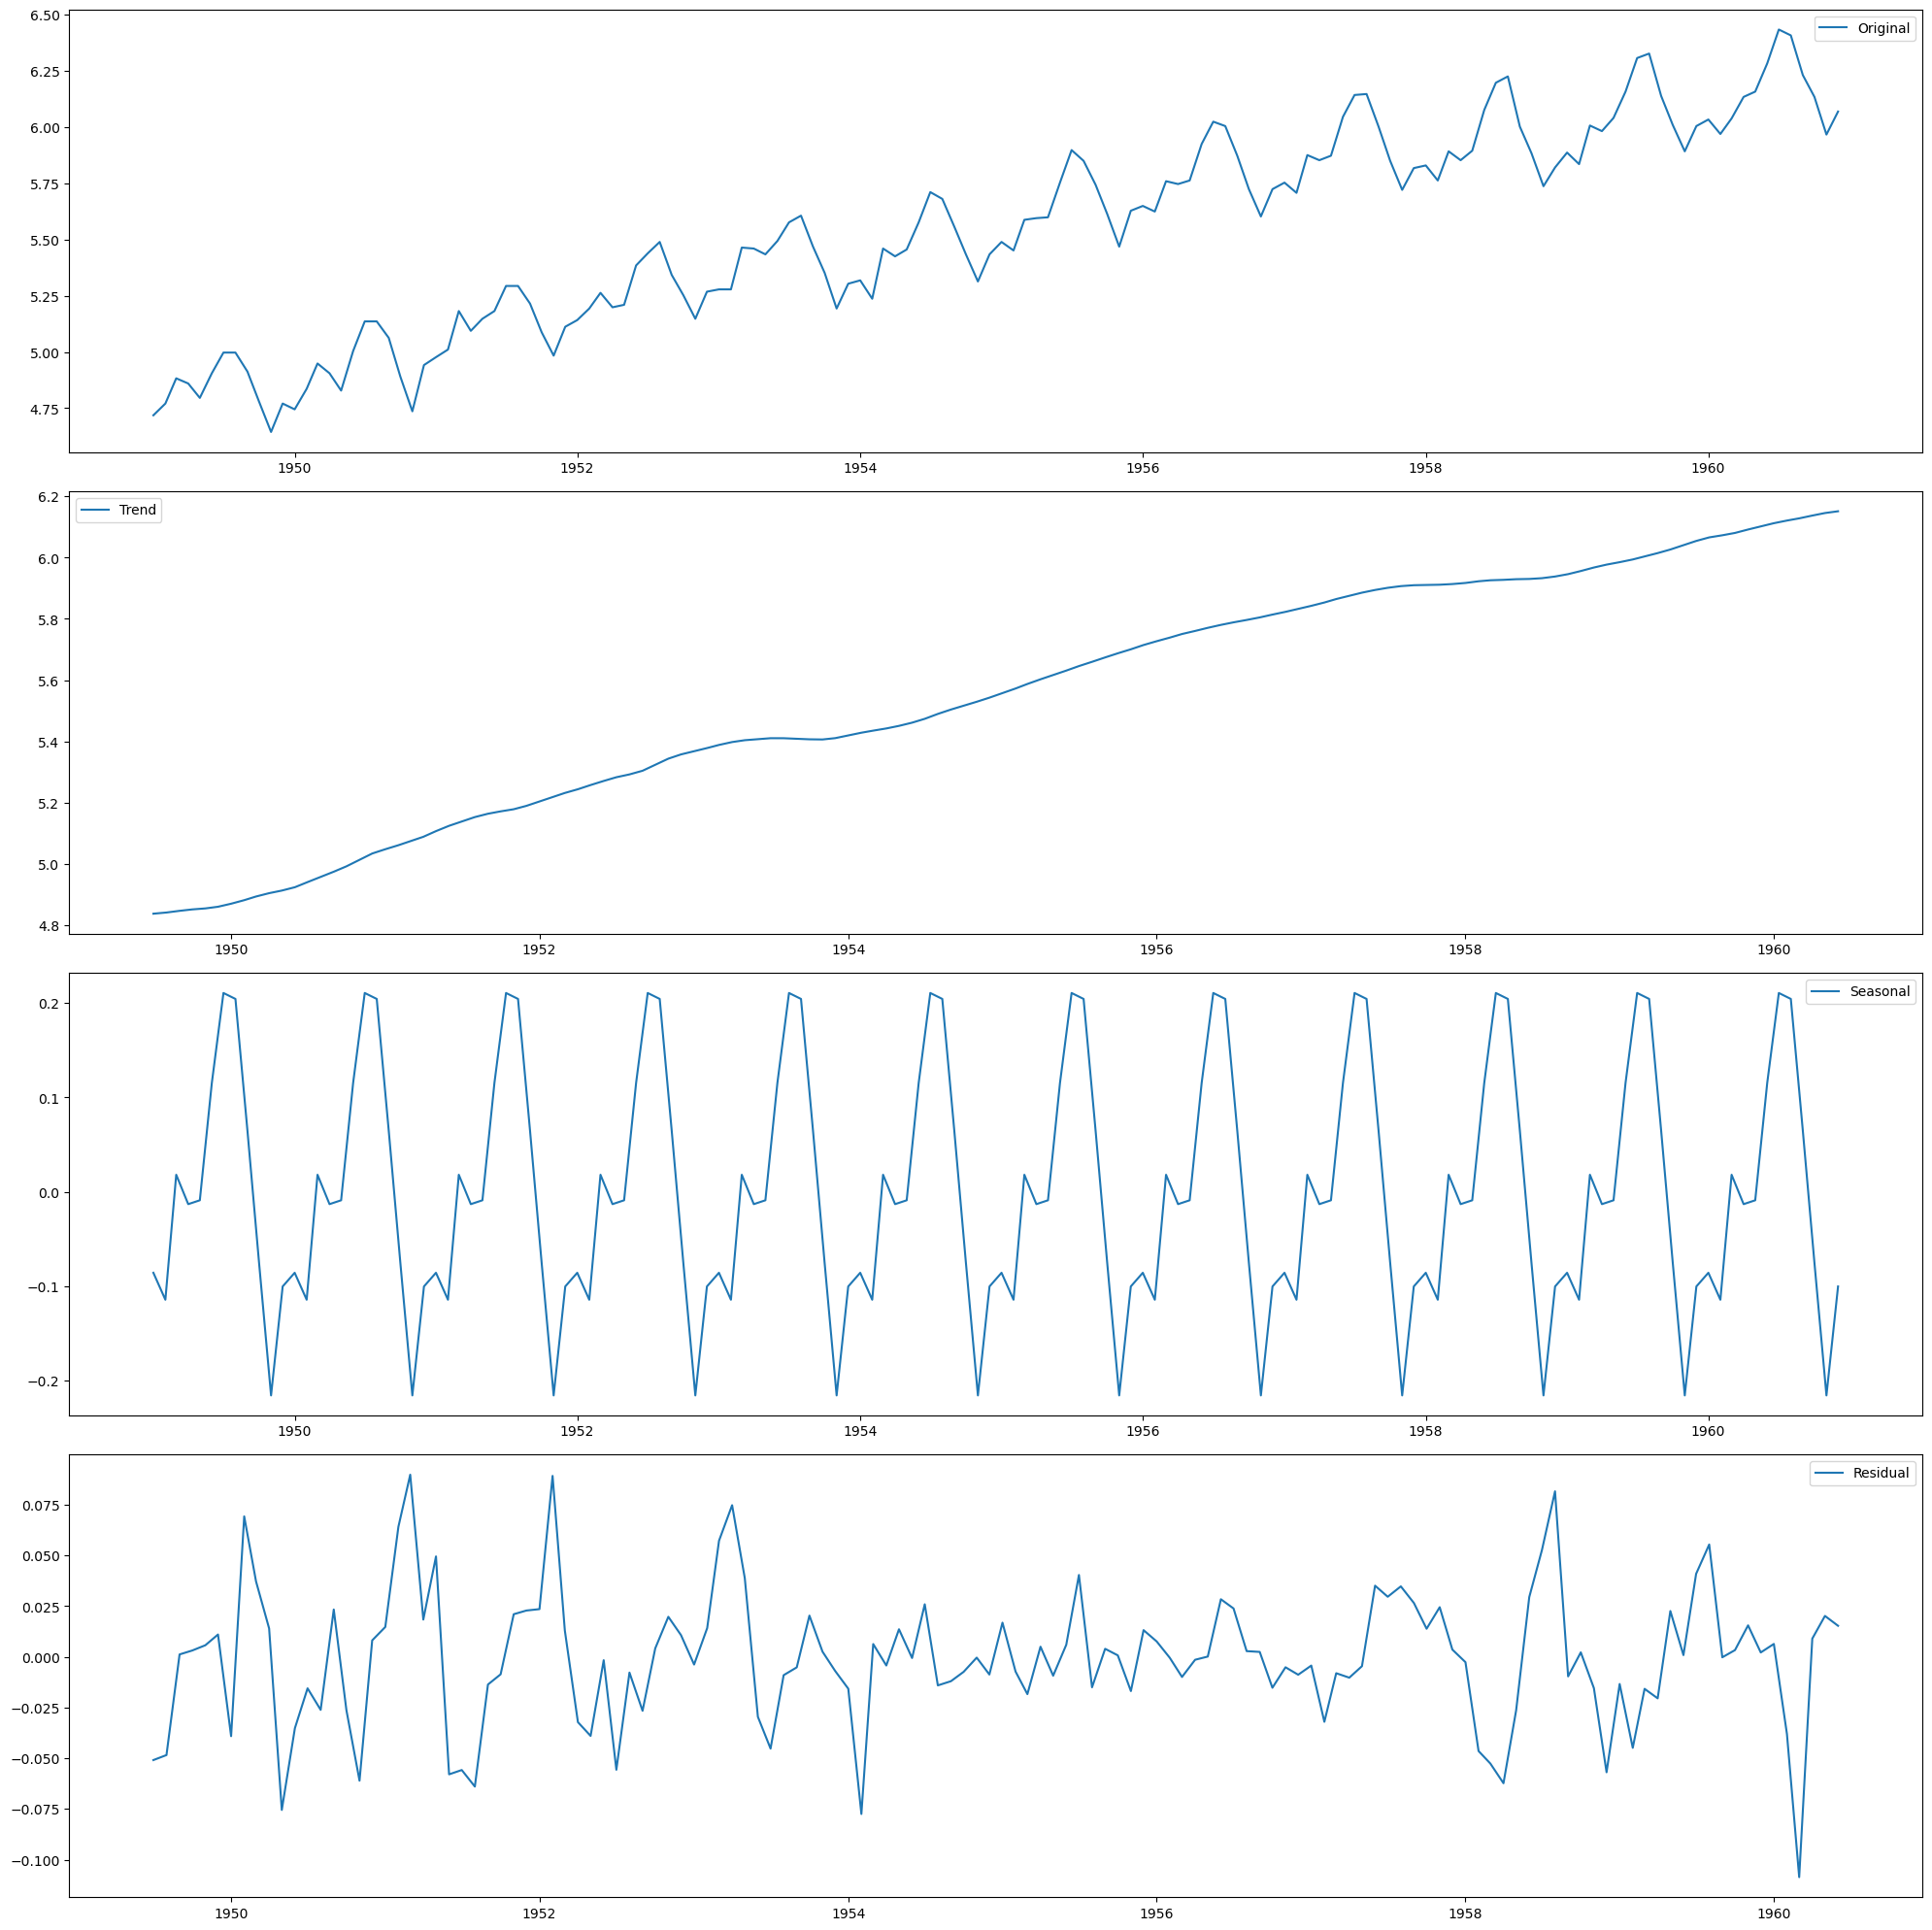

In [28]:
plt.figure(figsize=(20,20))
#Original TS LOGY Wala
plt.subplot(411)
plt.plot(ts_log, label="Original")
plt.legend(loc = 'best')
#Trend Graph
plt.subplot(412)
plt.plot(trend, label="Trend")
plt.legend(loc = 'best')
#Seasonal Graph
plt.subplot(413)
plt.plot(seasonal, label="Seasonal")
plt.legend(loc = 'best')
#Residual Graph
plt.subplot(414)
plt.plot(residual, label="Residual")
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [29]:
noise = residual

In [30]:
noise = residual.dropna()

### Decomposition say ham residuals nikaal dengay, baki seasonal or trend arima nikal lega

### d parameter → Trend ko remove karta hai (differencing se)
### S parameters → Seasonal patterns ko handle karta hai

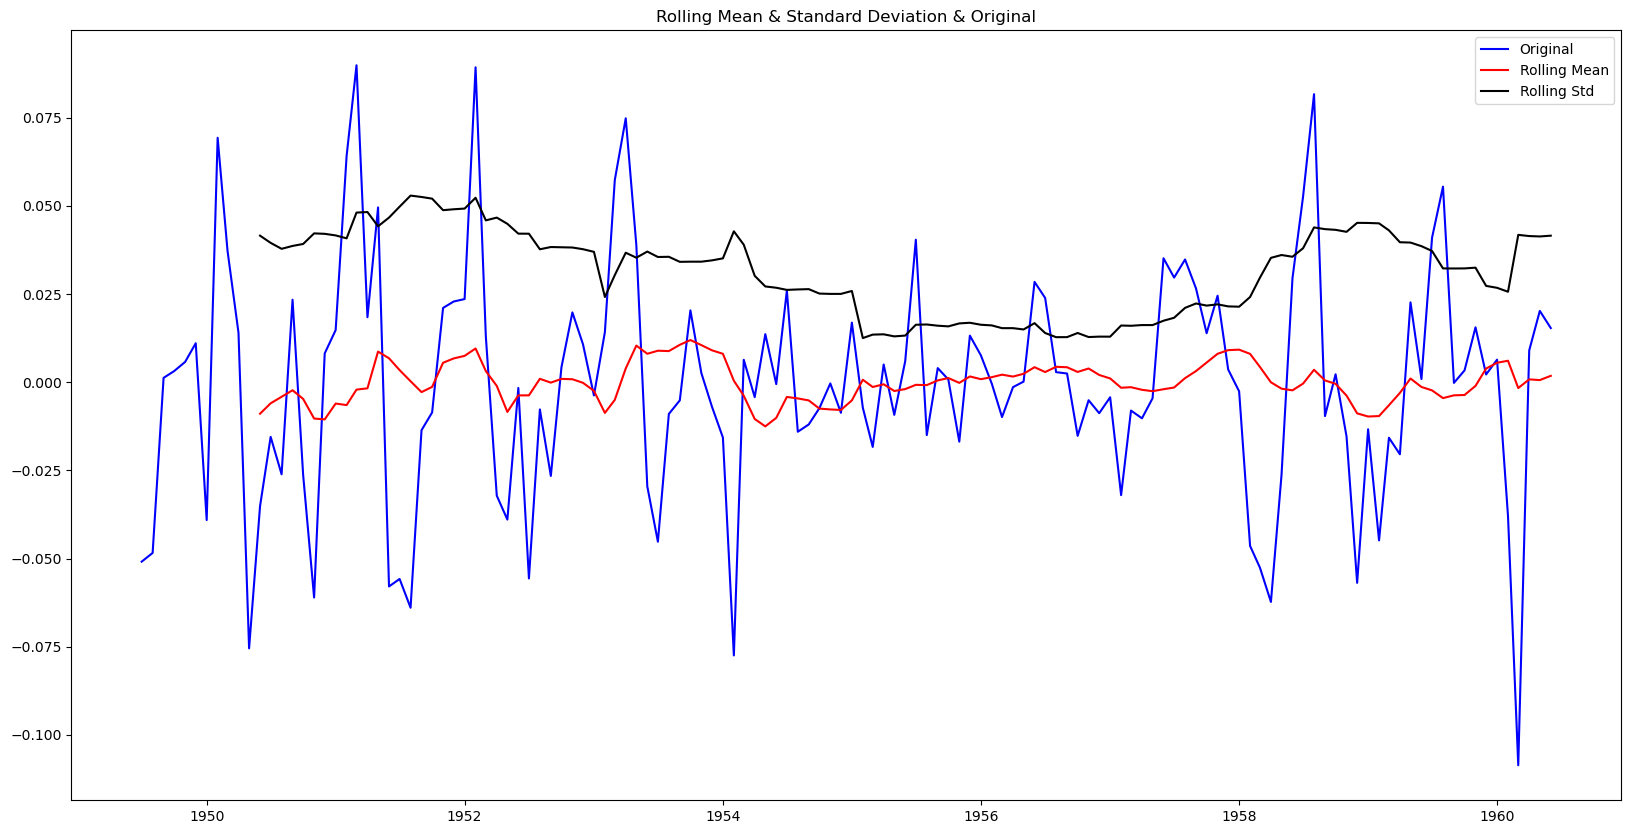

Results of ADFULLER TEST
Test Statistic                -6.332387e+00
p-value                        2.885059e-08
#Lags Used                     9.000000e+00
Number of Observations Used    1.220000e+02
Critical Value (1%)           -3.485122e+00
Critical Value (5%)           -2.885538e+00
Critical Value (10%)          -2.579569e+00
dtype: float64


In [31]:
stats_test(noise)

# Model Building

In [32]:
ts_values = ts_log.values

### Split into X and Y

In [33]:
X = ts_values
size = int(len(X) * 0.667)
Train, Test = X[0:size], X[size:len(X)]

In [34]:
len(Train)

96

In [35]:
len(Test)

48

### Now apply ARIMA Model

In [36]:
History = [x for x in Train]
predictions = list()

In [37]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [49]:
for t in range(len(Test)):
    model = ARIMA(History, order = (4,1,2))
    model_fit = model.fit()

    output = model_fit.forecast()

    yhat = output[0]
    predictions.append(yhat)
    actual = Test[t]
    History.append(actual)

    print(f"Actual = {actual}, Predicted = {yhat}") 

Actual = 5.752572638825633, Predicted = 6.164774348838439
Actual = 5.707110264748875, Predicted = 5.720186033988782
Actual = 5.87493073085203, Predicted = 5.851035500881632
Actual = 5.8522024797744745, Predicted = 5.90579261205142
Actual = 5.872117789475416, Predicted = 5.9859638050902015
Actual = 6.045005314036012, Predicted = 5.897687225408737
Actual = 6.142037405587356, Predicted = 6.089122205374541
Actual = 6.1463292576688975, Predicted = 6.140522141505395
Actual = 6.0014148779611505, Predicted = 6.128634471622433
Actual = 5.849324779946859, Predicted = 5.92967219774744
Actual = 5.720311776607412, Predicted = 5.823918314018838
Actual = 5.817111159963204, Predicted = 5.712112880165172
Actual = 5.8289456176102075, Predicted = 5.898479163606664
Actual = 5.762051382780177, Predicted = 5.862732268988364
Actual = 5.8916442118257715, Predicted = 5.818254578946555
Actual = 5.8522024797744745, Predicted = 5.926949783075749
Actual = 5.8944028342648505, Predicted = 5.851316396488255
Actual = 

In [39]:
error = mean_squared_error(Test, predictions)
rmse = mean_squared_error(Test, predictions)**0.5

print(f"Mean Squared Error: {error},\nRoot Mean Squared Error: {rmse}")

Mean Squared Error: 0.00962045209618676,
Root Mean Squared Error: 0.09808390334905498


### Now Visually see it

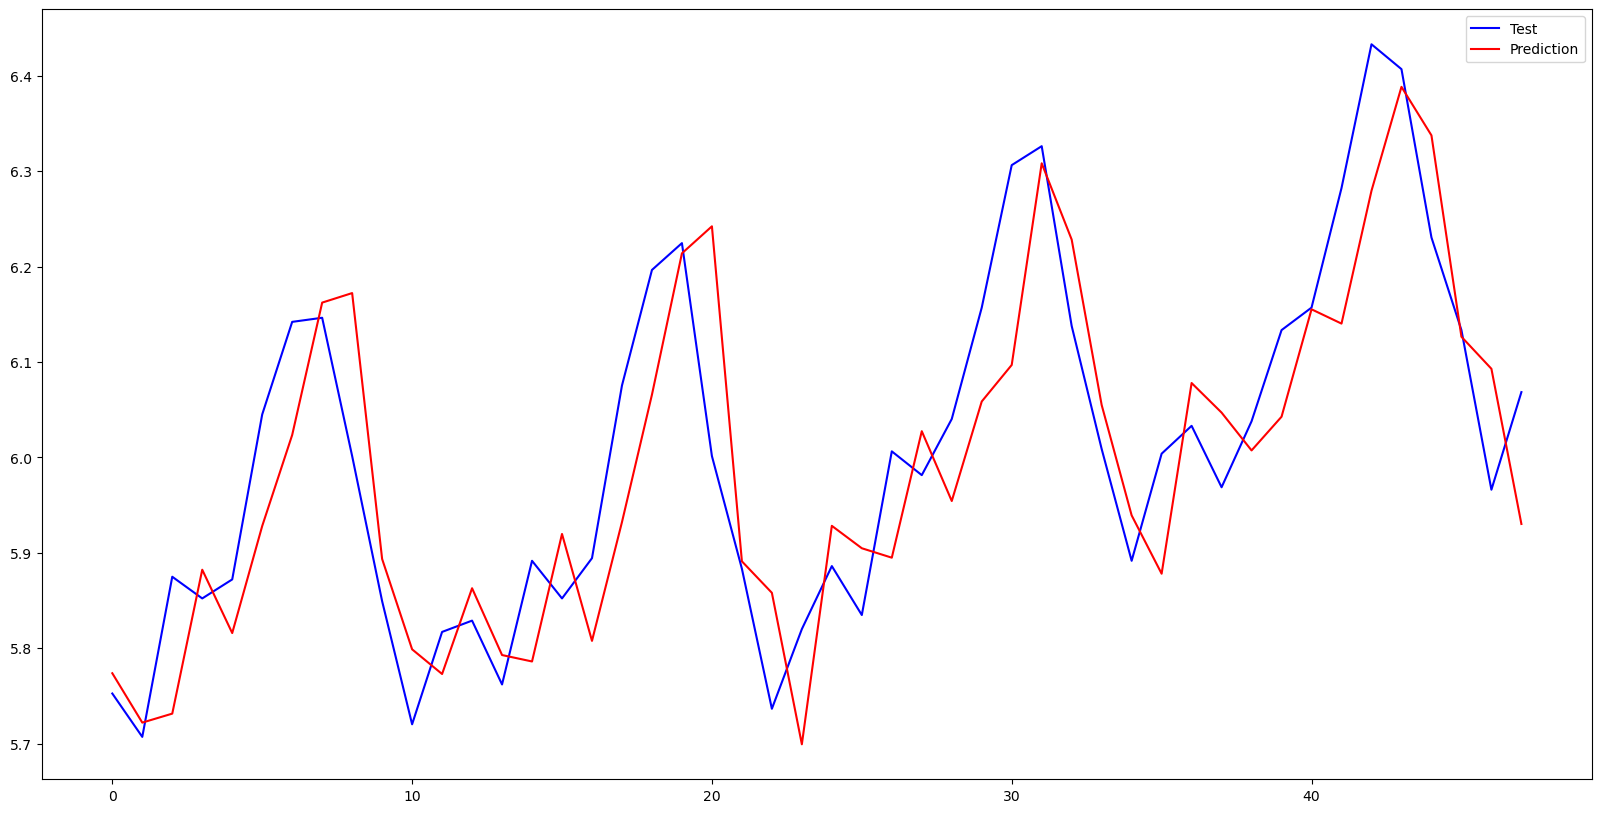

In [40]:
plt.figure(figsize=(20,10))
plt.plot(Test, color = 'blue', label='Test')   
plt.plot(predictions, color='red', label='Prediction')
plt.legend(loc='best')
plt.show()

## Ab yahi logi decomposition say na kay log say jo kay best hain

Actual = -0.005110398423877033, Predicted = -0.00998257490901481
Actual = -0.008791984298891803, Predicted = -0.005091817727037574
Actual = -0.004276975603170974, Predicted = -0.004077884571060451
Actual = -0.032017853766840645, Predicted = -0.0009018424983978711
Actual = -0.00804606036397643, Predicted = -0.011077766949395567
Actual = -0.010241877608440359, Predicted = 0.004926552731620069
Actual = -0.004569932730267057, Predicted = 0.004427941429721502
Actual = 0.03513686344404339, Predicted = 0.01153871396340448
Actual = 0.029666390441942025, Predicted = 0.016456971924253425
Actual = 0.034790857913778395, Predicted = 0.014574716364158427
Actual = 0.02656691745040618, Predicted = 0.00642403655099546
Actual = 0.013888040556412531, Predicted = 0.00027493072013391067
Actual = 0.024520840340428368, Predicted = -0.014534257023471341
Actual = 0.0035969468099680546, Predicted = -0.002714995695960865
Actual = -0.002599794971061775, Predicted = -0.02220613209131176
Actual = -0.046422695997376

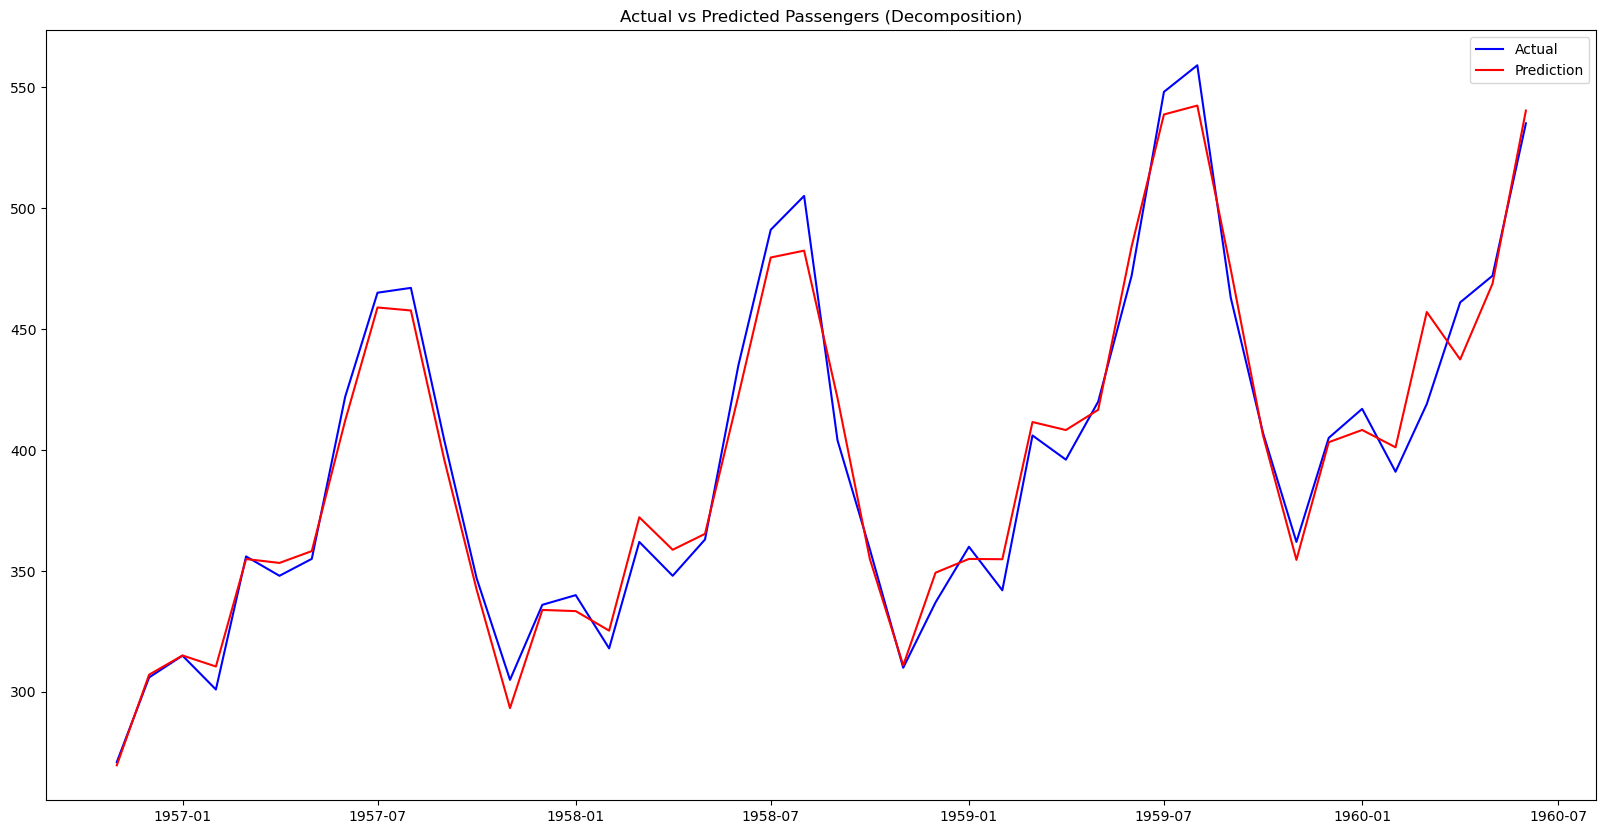

In [50]:
X1 = noise
size1 = int(len(X1) * 0.667)
Train1, Test1 = X1[0:size1], X1[size1:len(X1)]

History1 = list(Train1.values)
predictions1 = list()

for t1 in range(len(Test1)):
    model1 = ARIMA(History1, order=(2,0,2))
    model_fit1 = model1.fit()
    yhat1 = model_fit1.forecast()[0]
    
    predictions1.append(yhat1)
    actual1 = Test1.iloc[t1]
    History1.append(actual1)
    print(f"Actual = {actual1}, Predicted = {yhat1}")

predictions1 = pd.Series(predictions1, index=Test1.index)

print(f"RMSE (residual): {mean_squared_error(Test1, predictions1)**0.5}")

recon = np.exp(predictions1 + trend[Test1.index] + seasonal[Test1.index])
actual = ts[Test1.index]
print(f"RMSE (passengers): {mean_squared_error(actual, recon)**0.5}")

plt.figure(figsize=(20,10))
plt.plot(actual.index, actual, color='blue', label='Actual')
plt.plot(recon.index, recon, color='red', label='Prediction')
plt.legend(loc='best')
plt.title('Actual vs Predicted Passengers (Decomposition)')
plt.show()

# Grid Search

In [42]:
p_values = [1,2,3,4,5,6]
d_values = [0,1,2]
q_values = [1,2,3,4,5,6]

In [43]:
best_rmse, best_p, best_d, best_q = np.inf, None, None, None

In [44]:
History1 = list(Train1.values)
predictions1 = list()

In [48]:
for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            History1 = list(Train1.values)
            predictions1 = list()
            try:
              for t in range(len(Test1)):
                model = ARIMA(History1, order=order)
                model_fit = model.fit(disp=False, warn_for_convergence=False)
                yhat = model_fit.forecast()[0]
                predictions1.append(yhat)
                History1.append(Test1.iloc[t])

              # Calculate RMSE
              rmse = np.sqrt(mean_squared_error(Test1.values, predictions1))

              # Update best RMSE and parameter values
              if rmse < best_rmse:
                    best_rmse, best_p, best_d, best_q = rmse, p, d, q

            except:
                continue

print(f"Best RMSE: {best_rmse}")
print(f"Best p: {best_p}")
print(f"Best d: {best_d}")
print(f"Best q: {best_q}")

Best RMSE: 0.02662842291882326
Best p: 2
Best d: 0
Best q: 2


# Auto Arima

In [53]:
!pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB 

In [55]:
from pmdarima.arima import auto_arima

# Simple version
arima_model = auto_arima(
    Train1,
    max_p=6,
    max_d=2,
    max_q=6,
    m=12,                      # Seasonality (1 = no season, 12 = monthly)
    seasonal=True,           # Seasonal (True/False)
    stepwise=True,            # Smart search
    information_criterion='aic',
    suppress_warnings=True,
    error_action='trace'
)

arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   88
Model:               SARIMAX(3, 0, 1)   Log Likelihood                 190.480
Date:                Sat, 15 Aug 2026   AIC                           -368.959
Time:                        01:32:52   BIC                           -354.095
Sample:                    07-01-1949   HQIC                          -362.971
                         - 10-01-1956                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.957e-05      0.000     -0.071      0.944      -0.001       0.001
ar.L1          1.1360      0.096     11.802      0.000       0.947       1.325
ar.L2         -0.3213      0.143     -2.248      0.025      -0.602      -0.041
ar.L3         -0.1392      0.106     -1.311      0.190      -0.347       0.069
ma.L1         -0.9251      0.082    -11.219      0.000      -1.087      -0.763
sigma2         0.0007   8.77e-05      7.944      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 3.02
Prob(Q):                              0.85   Prob(JB):                         0.22
Heteroskedasticity (H):               0.20   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""